In this project, I will perform basic Exploratory Data Analysis (EDA) on the Kyphosis disease Dataset. Kyphosis is an abnormally excessive convex curvature of the spine. Dataset contains 81 rows and 4 columns representing data on children who have had corrective spinal surgery. 
    - INPUTS: 1. Age: in months, 2. Number: the number of vertebrae involved, 3. Start: the number of the first (topmost) vertebra operated on.
    - OUTPUTS: Kyphosis which represents a factor with levels absent present indicating if a kyphosis (a type of deformation) was present after the operation.
- Using the “kyphosis.csv" included in the course package, write a python script to perform the following tasks:
    1. Import the “kyphosis.csv" file using Pandas
    2. Perform basic Exploratory Data Analysis (EDA) on the data       
    3. List the average, minimum and maximum age (in years) considered in this study using 2 methods
    4. Plot the correlation matrix 
    5. Convert the age column datatype from int64 to float64
    6. Define a function that converts age from months to years 
    7. Apply the function to the “Age” column and add the results into a new column entitled “Age in Years” 
    8. What are the features of the oldest and youngest child in this study?
    9. Scale the raw Age column (in months) using both standardization and Normalization. Perform a sanity check. 

Step 1: Import the "kyphosis.csv" file using Pandas

In [1]:
import pandas as pd

In [2]:
kyphosis_df = pd.read_csv("/Users/graceenitan/Downloads/kyphosis.csv")
kyphosis_df

,Kyphosis,Age,Number,Start
0,absent,71,3,5
1,absent,158,3,14
2,present,128,4,5
3,absent,2,5,1
4,absent,1,4,15
...,...,...,...,...
76,present,157,3,13
77,absent,26,7,13
78,absent,120,2,13
79,present,42,7,6


In [3]:
# veryfying df type is DataFrame to work with Pandas libray
type(kyphosis_df)

pandas.DataFrame

In [4]:
print(kyphosis_df.dtypes)

Kyphosis      str
Age         int64
Number      int64
Start       int64
dtype: object


Summary: 

This dataset has multiple columns with varying data types like string and int64 (whole numbers). Important to note for future analysis when exploring using the age column.

Step 2: Perform basic Exploratory Data Analysis (EDA) on the data.

Basic EDA:

In [5]:
# viewing the top 5 records in df
kyphosis_df.head(5)

,Kyphosis,Age,Number,Start
0,absent,71,3,5
1,absent,158,3,14
2,present,128,4,5
3,absent,2,5,1
4,absent,1,4,15


In [6]:
# viewing the last 5 records in df
kyphosis_df.tail(5)

,Kyphosis,Age,Number,Start
76,present,157,3,13
77,absent,26,7,13
78,absent,120,2,13
79,present,42,7,6
80,absent,36,4,13


In [7]:
# viewing the df object descriptions - 
kyphosis_df.describe()

,Age,Number,Start
count,81.000000,81.000000,81.000000
mean,83.654321,4.049383,11.493827
std,58.104251,1.619423,4.883962
min,1.000000,2.000000,1.000000
25%,26.000000,3.000000,9.000000
50%,87.000000,4.000000,13.000000
75%,130.000000,5.000000,16.000000
max,206.000000,10.000000,18.000000


In [8]:
# viewing information on df objects
kyphosis_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Kyphosis  81 non-null     str  
 1   Age       81 non-null     int64
 2   Number    81 non-null     int64
 3   Start     81 non-null     int64
dtypes: int64(3), str(1)
memory usage: 2.7 KB


Step 3: Calculating the mean, minimum, and maximum ages of the children in years. 

In [9]:
# saving as variables to df
mean_age = kyphosis_df['Age'].mean()/12
max_age = kyphosis_df['Age'].max()/12
min_age = kyphosis_df['Age'].min()/12

In [10]:
# printing results
mean_age

np.float64(6.97119341563786)

In [11]:
max_age

np.float64(17.166666666666668)

In [12]:
min_age

np.float64(0.08333333333333333)

All datasets will contain anomalies like empty values, double checking for nulls to assess the validity in the previous calculations. Nulls values skew results.

In [13]:
# checking for nulls in df - display total
kyphosis_df.isnull().sum()

Kyphosis    0
Age         0
Number      0
Start       0
dtype: int64

Can confirm that there are no null values in this dataset. Further analysis can commence.

Step 4: Plot the correclation matrix.

Assessing the correlation between the variables in the dataset.

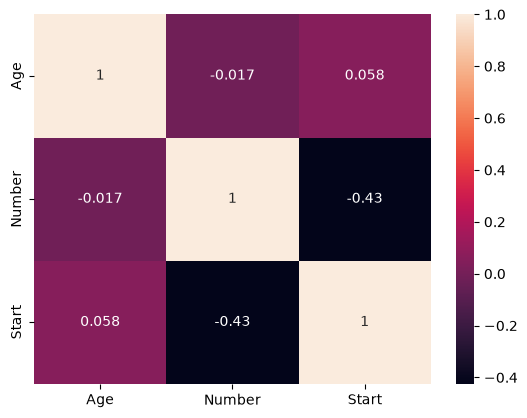

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.heatmap(kyphosis_df.corr(numeric_only=True), annot=True);

Step 5: Convert the age column data type from int64 to float64.

In [16]:
# conversion function
kyphosis_df['Age'] = kyphosis_df['Age'].astype("float64")

In [17]:
kyphosis_df['Age'].info()

<class 'pandas.Series'>
RangeIndex: 81 entries, 0 to 80
Series name: Age
Non-Null Count  Dtype  
--------------  -----  
81 non-null     float64
dtypes: float64(1)
memory usage: 780.0 bytes


Steps 6 & 7: Define a function that converts age from months to years. Apply the function to the “Age” column and add the results into a new column entitled “Age in Years” 

In [18]:
# define a function that converts the age values from months to years - divide by 12 to get year
def month_to_year(age):
    return age /12

In [19]:
# apply the age function to the 'Age' column, then reassign the results into a new column- name it 'Age in Years'
kyphosis_df['Age in Years'] = kyphosis_df['Age'].apply(month_to_year)
kyphosis_df['Age in Years'].info()

<class 'pandas.Series'>
RangeIndex: 81 entries, 0 to 80
Series name: Age in Years
Non-Null Count  Dtype  
--------------  -----  
81 non-null     float64
dtypes: float64(1)
memory usage: 780.0 bytes


In [20]:
kyphosis_df

,Kyphosis,Age,Number,Start,Age in Years
0,absent,71.0,3,5,5.916667
1,absent,158.0,3,14,13.166667
2,present,128.0,4,5,10.666667
3,absent,2.0,5,1,0.166667
4,absent,1.0,4,15,0.083333
...,...,...,...,...,...
76,present,157.0,3,13,13.083333
77,absent,26.0,7,13,2.166667
78,absent,120.0,2,13,10.000000
79,present,42.0,7,6,3.500000


Step 8: Features of the oldest and youngest child in the study.

In [21]:
# features of oldest child
kyphosis_df[ kyphosis_df['Age'] == kyphosis_df['Age'].max() ]

,Kyphosis,Age,Number,Start,Age in Years
73,absent,206.0,4,10,17.166667


In [22]:
# features of youngest child(ren)
kyphosis_df[ kyphosis_df['Age'] == kyphosis_df['Age'].min() ]

,Kyphosis,Age,Number,Start,Age in Years
4,absent,1.0,4,15,0.083333
5,absent,1.0,2,16,0.083333
13,absent,1.0,4,12,0.083333
15,absent,1.0,3,16,0.083333
36,absent,1.0,3,9,0.083333


Step 9: Scaling the raw Age column (in months) using standardization and normalization. Then perform sanity check.

In [24]:
# re-importing kyphosis.csv
df = pd.read_csv("/Users/graceenitan/Downloads/kyphosis.csv")
df

,Kyphosis,Age,Number,Start
0,absent,71,3,5
1,absent,158,3,14
2,present,128,4,5
3,absent,2,5,1
4,absent,1,4,15
...,...,...,...,...
76,present,157,3,13
77,absent,26,7,13
78,absent,120,2,13
79,present,42,7,6


In [25]:
# importing scaler for standardization 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df['Age'] = scaler.fit_transform(df['Age'].values.reshape(-1, 1))

In [26]:
df['Age']

0    -0.219143
1     1.287494
2     0.767964
3    -1.414063
4    -1.431381
        ...   
76    1.270177
77   -0.998439
78    0.629423
79   -0.721356
80   -0.825262
Name: Age, Length: 81, dtype: float64

In [27]:
df['Age'].describe().round(2)

count    81.00
mean      0.00
std       1.01
min      -1.43
25%      -1.00
50%       0.06
75%       0.80
max       2.12
Name: Age, dtype: float64

In [28]:
# re-importing df kyphosis.csv
df = pd.read_csv("/Users/graceenitan/Downloads/kyphosis.csv")
df

,Kyphosis,Age,Number,Start
0,absent,71,3,5
1,absent,158,3,14
2,present,128,4,5
3,absent,2,5,1
4,absent,1,4,15
...,...,...,...,...
76,present,157,3,13
77,absent,26,7,13
78,absent,120,2,13
79,present,42,7,6


In [29]:
# importing MinMaxScaler for normalization
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df['Age'] = scaler.fit_transform(df['Age'].values.reshape(-1, 1))

In [30]:
df['Age']

0     0.341463
1     0.765854
2     0.619512
3     0.004878
4     0.000000
        ...   
76    0.760976
77    0.121951
78    0.580488
79    0.200000
80    0.170732
Name: Age, Length: 81, dtype: float64

In [31]:
df['Age'].describe()

count    81.000000
mean      0.403192
std       0.283435
min       0.000000
25%       0.121951
50%       0.419512
75%       0.629268
max       1.000000
Name: Age, dtype: float64